<a href="https://colab.research.google.com/github/Dharshan1825/Video-Game-Global-Sales-Analysis/blob/main/vga.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 Video Games Sales Insight Report- EDA

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

# Load dataset
df = pd.read_csv("/content/game_sales_merged.csv")

# Preview
df.head()


,merged_id,game_title,game_id,vgsales_rank,platform,genre,publisher,release_year,rating,global_sales,plays,wishlist,merge_date
0,1,Advance Wars,NaN,2925,gba,strategy,nintendo,2001,3.7,0.70,1900,266000,04-10-2025
1,2,Alan Wake,NaN,1444,x360,action,microsoft game studios,2010,3.6,1.35,6200,741000,04-10-2025
2,3,Alice: Madness Returns,NaN,3956,x360,adventure,electronic arts,2011,3.5,0.50,2800,636000,04-10-2025
3,4,Alice: Madness Returns,NaN,9789,pc,adventure,electronic arts,2011,3.5,0.12,2800,636000,04-10-2025
4,5,Alice: Madness Returns,NaN,3352,ps3,adventure,electronic arts,2011,3.5,0.60,2800,636000,04-10-2025


In [ ]:
print("Dataset Shape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())


Dataset Shape: (1012, 13)

Columns:
 Index(['merged_id', 'game_title', 'game_id', 'vgsales_rank', 'platform',
       'genre', 'publisher', 'release_year', 'rating', 'global_sales', 'plays',
       'wishlist', 'merge_date'],
      dtype='object')

Data Types:
 merged_id         int64
game_title       object
game_id         float64
vgsales_rank      int64
platform         object
genre            object
publisher        object
release_year      int64
rating          float64
global_sales    float64
plays             int64
wishlist          int64
merge_date       object
dtype: object

Missing Values:
 merged_id          0
game_title         0
game_id         1012
vgsales_rank       0
platform           0
genre              0
publisher          0
release_year       0
rating             0
global_sales       0
plays              0
wishlist           0
merge_date         0
dtype: int64


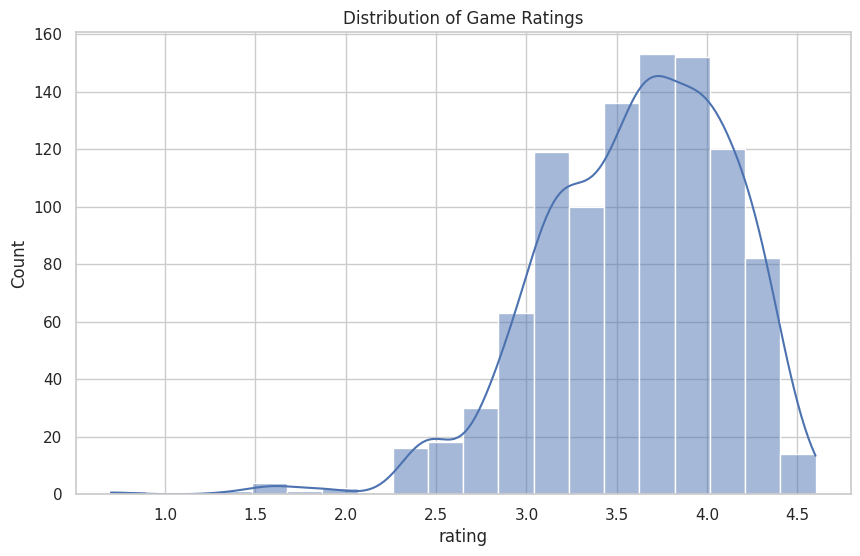

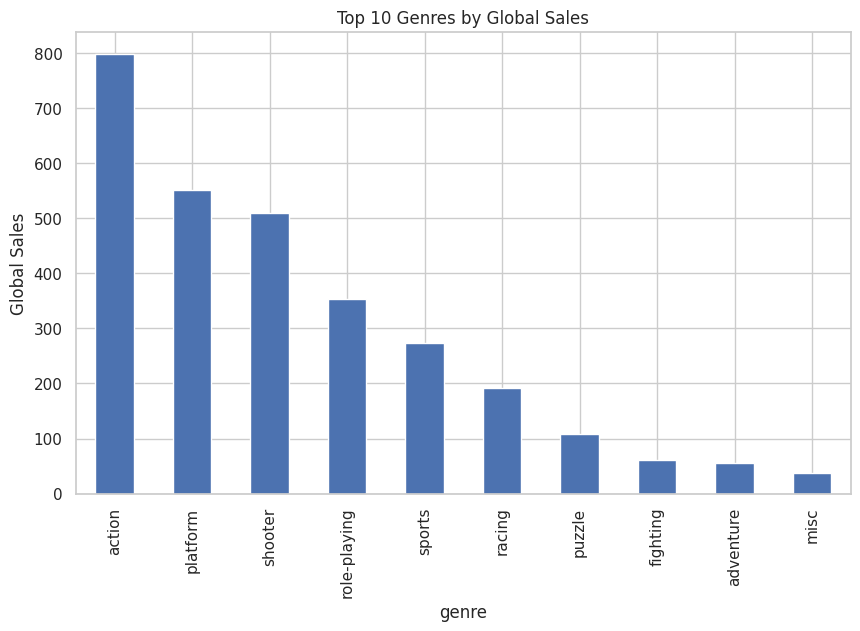

In [ ]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
df.columns
sns.histplot(df["rating"], bins=20, kde=True)
plt.title("Distribution of Game Ratings")
plt.show()
genre_sales = df.groupby("genre")["global_sales"].sum().sort_values(ascending=False)

genre_sales.head(10).plot(kind="bar")
plt.title("Top 10 Genres by Global Sales")
plt.ylabel("Global Sales")
plt.show()


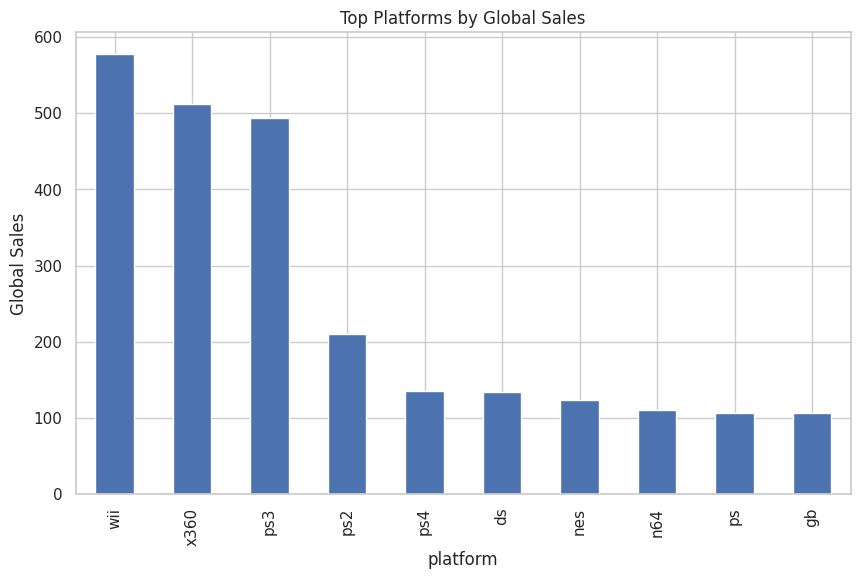

In [ ]:
platform_sales = df.groupby("platform")["global_sales"].sum().sort_values(ascending=False)

platform_sales.head(10).plot(kind="bar")
plt.title("Top Platforms by Global Sales")
plt.ylabel("Global Sales")
plt.show()


Cannot plot regional distribution. Missing columns: ['na_sales', 'eu_sales', 'jp_sales', 'other_sales']
Plotting Global Sales summary instead:


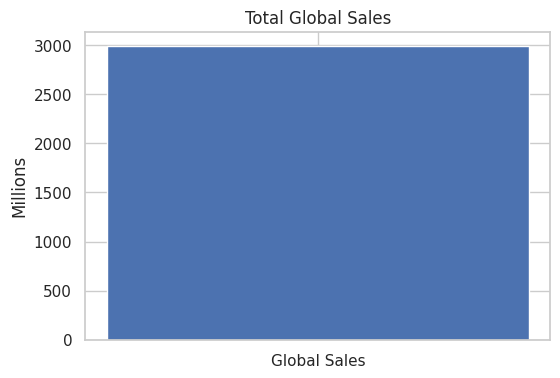

In [ ]:
# The error occurred because regional columns (na_sales, eu_sales, etc.) are not in this dataset.
# Checking available columns and plotting global_sales instead if regions are missing.

regional_cols = ['na_sales', 'eu_sales', 'jp_sales', 'other_sales']
missing_cols = [col for col in regional_cols if col not in df.columns]

if not missing_cols:
    regional_sales = df[regional_cols].sum()
    regional_sales.plot(kind="bar")
    plt.title("Regional Sales Distribution")
    plt.ylabel("Total Sales")
    plt.show()
else:
    print(f"Cannot plot regional distribution. Missing columns: {missing_cols}")
    print("Plotting Global Sales summary instead:")
    plt.figure(figsize=(6,4))
    plt.bar(['Global Sales'], [df['global_sales'].sum()])
    plt.title("Total Global Sales")
    plt.ylabel("Millions")
    plt.show()

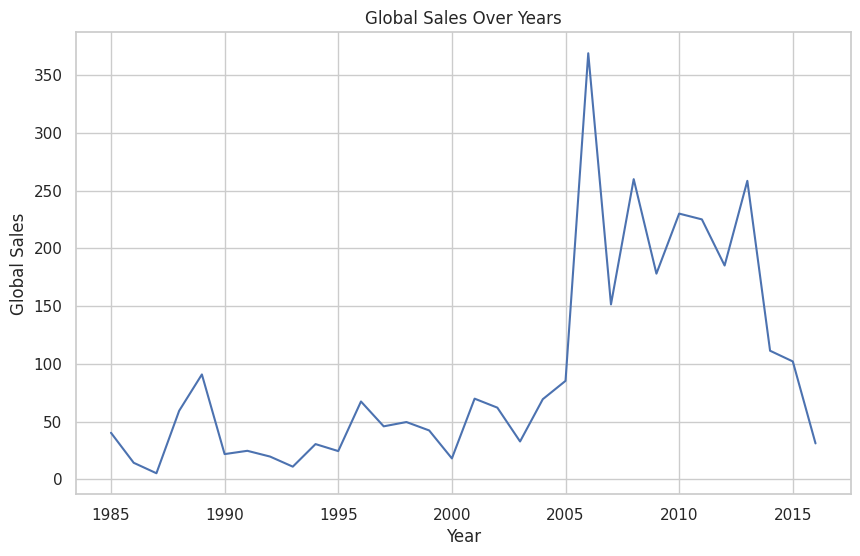

In [ ]:
yearly_sales = df.groupby("release_year")["global_sales"].sum()

yearly_sales.plot()
plt.title("Global Sales Over Years")
plt.xlabel("Year")
plt.ylabel("Global Sales")
plt.show()


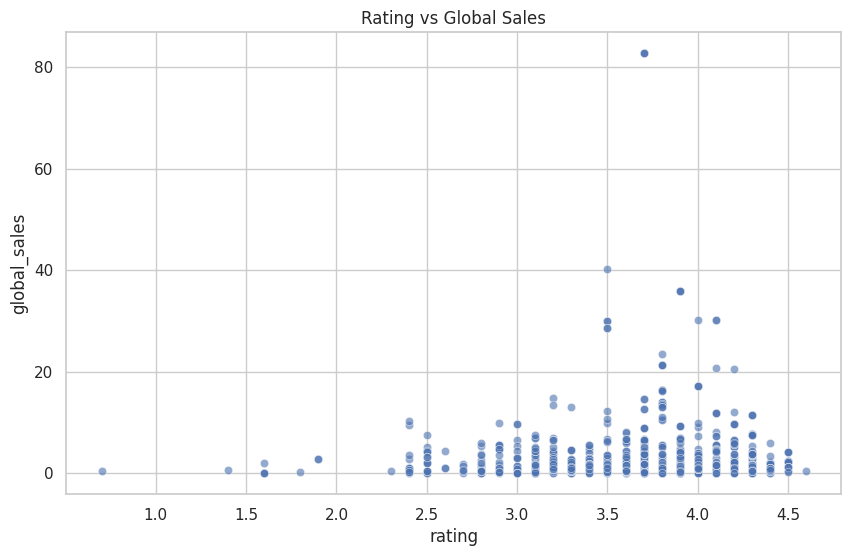

In [ ]:
sns.scatterplot(data=df, x="rating", y="global_sales", alpha=0.6)
plt.title("Rating vs Global Sales")
plt.show()


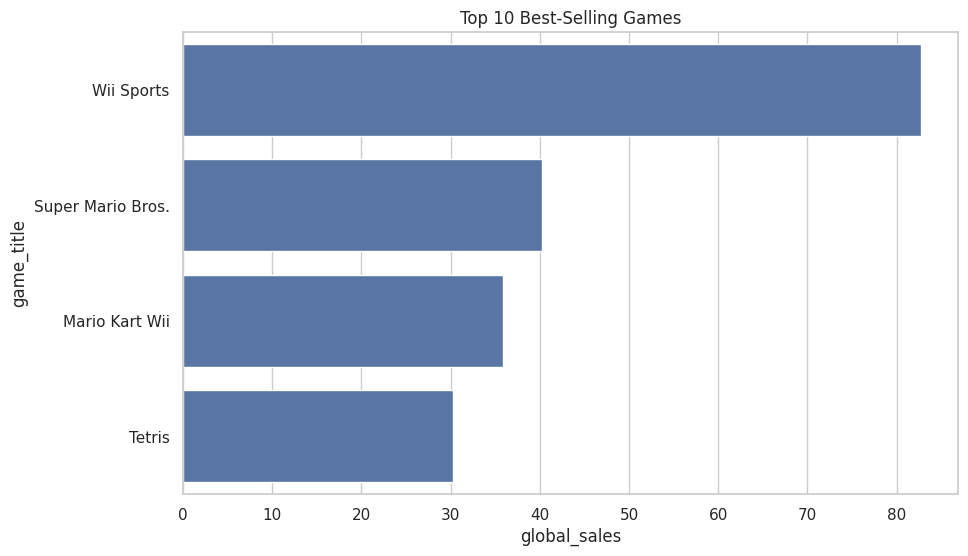

In [ ]:
top_games = df.sort_values(by="global_sales", ascending=False).head(10)

sns.barplot(data=top_games, x="global_sales", y="game_title")
plt.title("Top 10 Best-Selling Games")
plt.show()

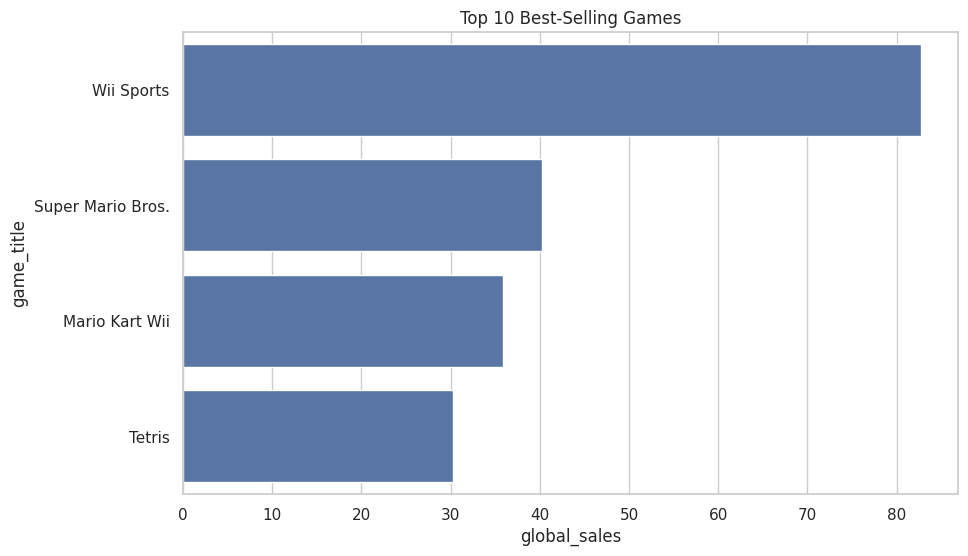

In [ ]:
top_games = df.sort_values(by="global_sales", ascending=False).head(10)

sns.barplot(data=top_games, x="global_sales", y="game_title")
plt.title("Top 10 Best-Selling Games")
plt.show()

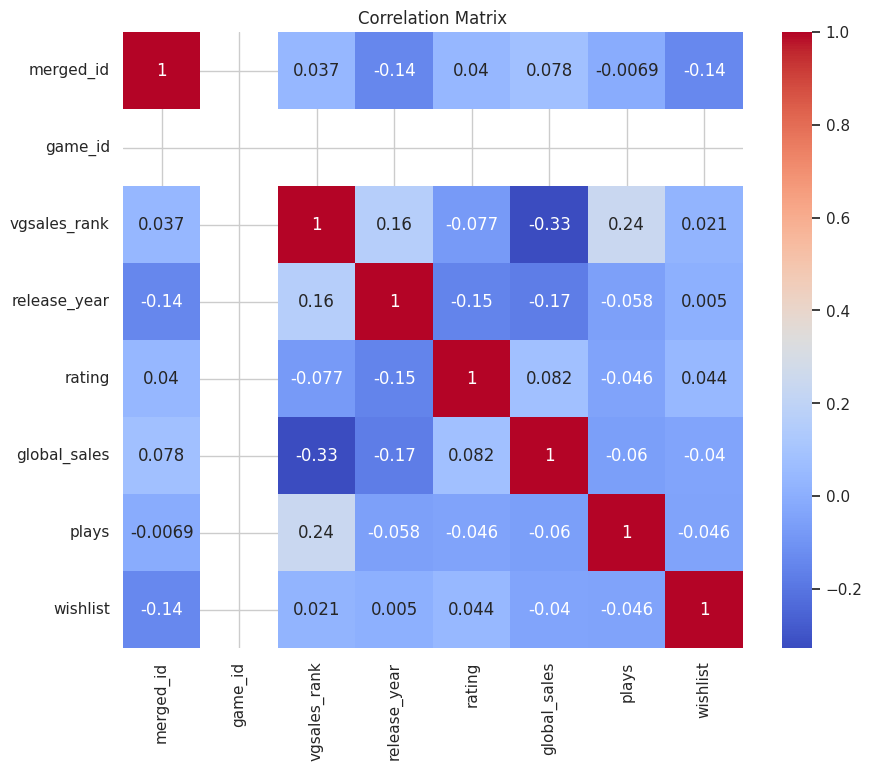

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()
